<a href="https://colab.research.google.com/github/Mohamad-Selawy/Python/blob/master/Data%20Analysis/Level%202/correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Correlation**

_Correlation is essential tool for understanding relationships between numerical variables._


## What You'll Learn
- What correlation mean
- How to compute it in pandas
- How to visualize relationships using a heatmap

## Concepts
- **Correlation**: Measures the strength and direction of a linear relationship between two variables. Ranges between -1 and 1.



## Types of Correlation

There are three main types of correlation:

1.  **Positive Correlation**: As one variable increases, the other variable also tends to increase. For example, hours studied and exam scores.
2.  **Negative Correlation**: As one variable increases, the other variable tends to decrease. For example, hours spent exercising and weight.
3.  **No Correlation**: There is no consistent relationship between the two variables. For example, shoe size and intelligence.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Sample Dataset
We’ll create a small DataFrame to work with:

In [ ]:
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7],
    'Exam_Score': [50, 55, 65, 70, 75, 85, 90],
    'Sleep_Hours': [8, 7, 6, 6, 5, 4, 3]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Exam_Score,Sleep_Hours
0,1,50,8
1,2,55,7
2,3,65,6
3,4,70,6
4,5,75,5
5,6,85,4
6,7,90,3


### 1. Correlation - .corr()

In [ ]:
df.corr()

,Hours_Studied,Exam_Score,Sleep_Hours
Hours_Studied,1.000000,0.995871,-0.987829
Exam_Score,0.995871,1.000000,-0.988457
Sleep_Hours,-0.987829,-0.988457,1.000000


Interpretation:

- `Hours_Studied` and `Exam_Score` should show a strong positive correlation.

- `Sleep_Hours` and `Hours_Studied` should show a negative correlation (studying more → less sleep).


#### Visualizing Correlation


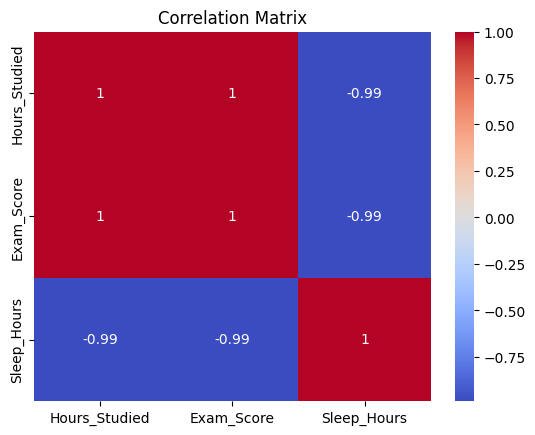

In [ ]:
# @title
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Example 1: Posetive Correlation

In [ ]:
import pandas as pd
data_positive = {
    'Income': [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000],
    'Spending': [20000, 23000, 25000, 28000, 30000, 32000, 35000, 38000, 40000, 43000, 45000, 48000, 50000, 53000, 55000]
}
df_positive = pd.DataFrame(data_positive)
display(df_positive)

,Income,Spending
0,30000,20000
1,35000,23000
2,40000,25000
3,45000,28000
4,50000,30000
5,55000,32000
6,60000,35000
7,65000,38000
8,70000,40000
9,75000,43000


In [ ]:
display(df_positive.corr())

,Income,Spending
Income,1.000000,0.999625
Spending,0.999625,1.000000


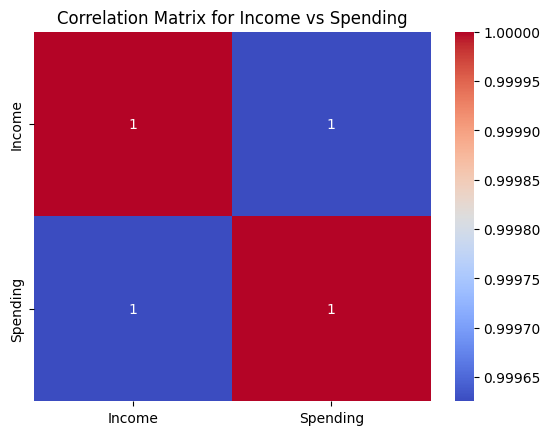

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_positive.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Income vs Spending")
plt.show()

# Example 2: Correlation

In [ ]:
import pandas as pd
data = {
    'Num_Daily_Coffees': [0, 0, 0, 0.5, 0.5, 1, 1, 2, 0, 3, 1, 4, 2, 0, 1], # Adjusted to include low coffee for children
    'Age': [8, 10, 12, 14, 16, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65] # Ages from children to adults
}
df_coffees_age = pd.DataFrame(data)
display(df_coffees_age)

,Num_Daily_Coffees,Age
0,0.0,8
1,0.0,10
2,0.0,12
3,0.5,14
4,0.5,16
5,1.0,20
6,1.0,25
7,2.0,30
8,0.0,35
9,3.0,40


In [ ]:
display(df_coffees_age.corr())

,Num_Daily_Coffees,Age
Num_Daily_Coffees,1.000000,0.437534
Age,0.437534,1.000000


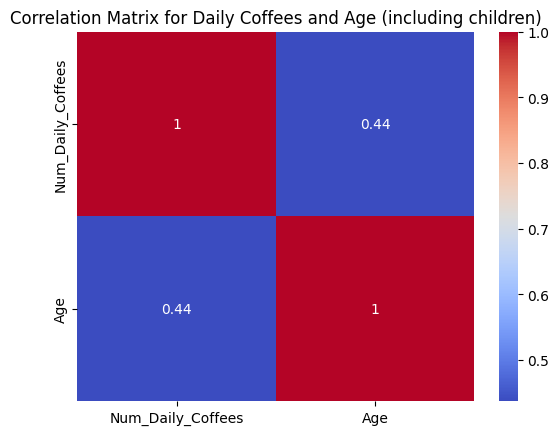

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_coffees_age.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Daily Coffees and Age (including children)")
plt.show()

**Now, let's look at the average number of daily coffees for each age group.**

The `pd.cut()` function in pandas is used to segment and sort data values into bins. This is particularly useful for converting continuous numerical data into discrete categorical data (i.e., binning).

Key arguments:

-   `x`: The input array to be binned (e.g., a Series or DataFrame column).
-   `bins`: Defines the bin edges. This can be an integer (for equally spaced bins), a sequence of scalars (for custom bin edges), or a pandas IntervalIndex.
-   `labels`: Specifies the labels for the returned bins. This should be the same length as the number of bins. If `False`, returns integer indicators of the bins.
-   `right`: A boolean indicating whether the bins include the rightmost edge. If `True` (default), bins are `(a, b]` (left open, right closed). If `False`, bins are `[a, b)` (left closed, right open).

In the context of the code, `pd.cut` is used to categorize the 'Age' column into predefined age groups using the `bins` and `labels` provided.

In [ ]:
# Create age categories
bins = [0, 13, 20, 30, 50, np.inf]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df_coffees_age['Age_Group'] = pd.cut(df_coffees_age['Age'], bins=bins, labels=labels, right=False)

display(df_coffees_age)

,Num_Daily_Coffees,Age,Age_Group
0,0.0,8,Child
1,0.0,10,Child
2,0.0,12,Child
3,0.5,14,Teen
4,0.5,16,Teen
5,1.0,20,Young Adult
6,1.0,25,Young Adult
7,2.0,30,Adult
8,0.0,35,Adult
9,3.0,40,Adult


In [ ]:
avg_coffees_by_age_group = df_coffees_age.groupby('Age_Group')['Num_Daily_Coffees'].mean().reset_index()
avg_coffees_by_age_group

/tmp/ipykernel_1909/1865187733.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_coffees_by_age_group = df_coffees_age.groupby('Age_Group')['Num_Daily_Coffees'].mean().reset_index()


,Age_Group,Num_Daily_Coffees
0,Child,0.00
1,Teen,0.50
2,Young Adult,1.00
3,Adult,1.50
4,Senior,1.75


This shows a clearer relationship: children consume no coffee, while older groups show increasing averages. We can also visualize this relationship.

/tmp/ipykernel_1909/1197094895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Num_Daily_Coffees', data=avg_coffees_by_age_group, palette='viridis')


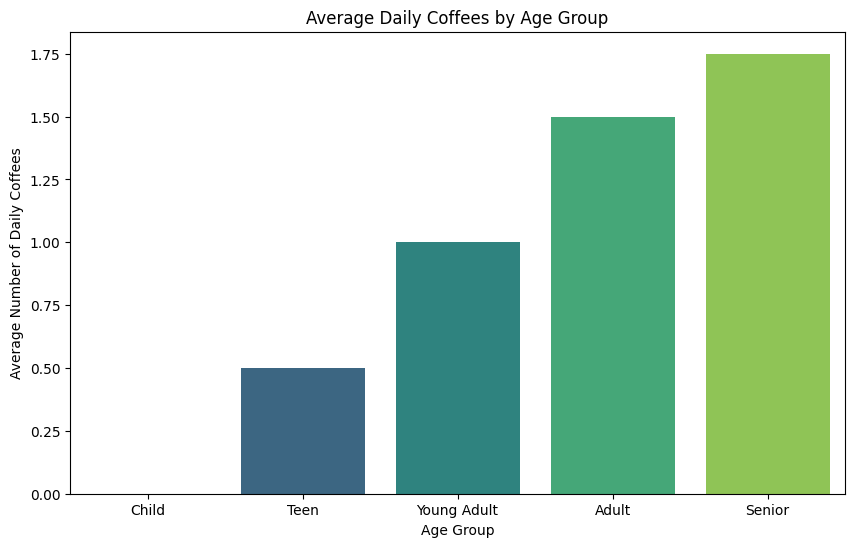

In [ ]:
# @title
plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Num_Daily_Coffees', data=avg_coffees_by_age_group, palette='viridis')
plt.title('Average Daily Coffees by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Number of Daily Coffees')
plt.show()

### Example 4: No Correlation Example

In [ ]:
data_no_corr = {
    'Daily_Steps': [5000, 7000, 3000, 10000, 6000, 8000, 4000, 9000, 2000, 11000, 7500, 5500, 9500, 3500, 6500],
    'Amount_Spent_On_Books': [20, 50, 10, 30, 70, 25, 45, 15, 60, 35, 80, 40, 55, 65, 5]
}
df_no_correlation = pd.DataFrame(data_no_corr)
display(df_no_correlation)

,Daily_Steps,Amount_Spent_On_Books
0,5000,20
1,7000,50
2,3000,10
3,10000,30
4,6000,70
5,8000,25
6,4000,45
7,9000,15
8,2000,60
9,11000,35


In [ ]:
print("Correlation Matrix for Daily Steps vs Amount Spent On Books:")
display(df_no_correlation.corr())

Correlation Matrix for Daily Steps vs Amount Spent On Books:


,Daily_Steps,Amount_Spent_On_Books
Daily_Steps,1.000000,-0.126532
Amount_Spent_On_Books,-0.126532,1.000000


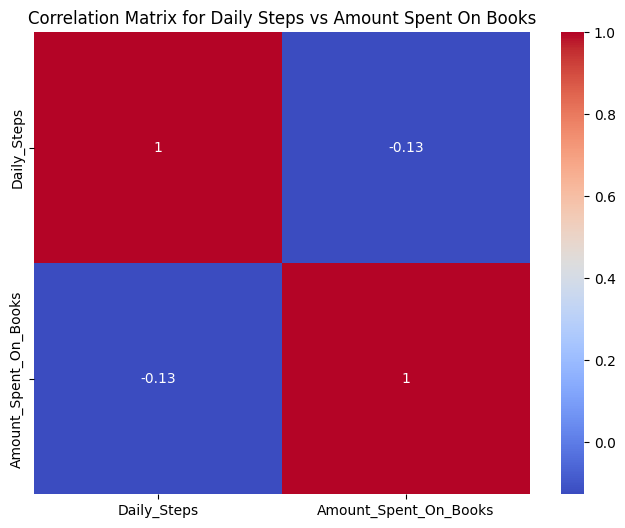

In [ ]:
# @title
plt.figure(figsize=(8, 6))
sns.heatmap(df_no_correlation.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Daily Steps vs Amount Spent On Books")
plt.show()

### Example 5: Negative Correlation Example

In [10]:
data_negative = {
    'Study_Hours': [10, 8, 6, 5, 5, 4, 3, 2, 1],
    'Exam_Score': [50, 55, 65, 70, 75, 85, 90, 100, 95],
    'Gaming_Hours': [1, 2, 3, 4, 5, 5, 6, 8, 9]
}
df_study_gaming = pd.DataFrame(data_negative)
display(df_study_gaming)

,Study_Hours,Exam_Score,Gaming_Hours
0,10,50,1
1,8,55,2
2,6,65,3
3,5,70,4
4,5,75,5
5,4,85,5
6,3,90,6
7,2,100,8
8,1,95,9


In [11]:
print("Correlation Matrix for Study Hours vs Gaming Hours:")
display(df_study_gaming.corr())

Correlation Matrix for Study Hours vs Gaming Hours:


,Study_Hours,Exam_Score,Gaming_Hours
Study_Hours,1.000000,-0.967693,-0.969706
Exam_Score,-0.967693,1.000000,0.960665
Gaming_Hours,-0.969706,0.960665,1.000000


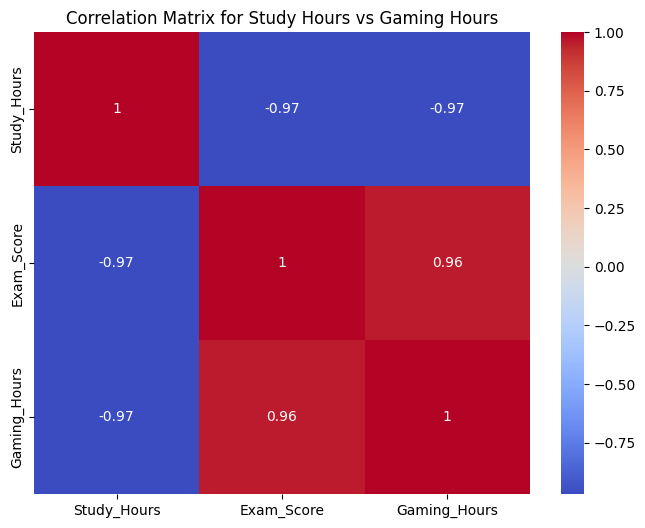

In [12]:
# @title
plt.figure(figsize=(8, 6))
sns.heatmap(df_study_gaming.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Study Hours vs Gaming Hours")
plt.show()

## When to Use

| Use Case                  | Use         |
|:------------------------- |:----------- |
| Normalize strength        | Correlation |


## Summary

| Concept     | Description                     | Range   |
|:----------- |:------------------------------- |:------- |
| Correlation | Strength of linear relationship | -1 to 1 |

## Exercises

Now, try these exercises to deepen your understanding of correlation!

### Exercise 1: Create a Dataset and Calculate Correlation

Create a pandas DataFrame with two columns, `Temperature` (in Celsius) and `Ice_Cream_Sales` (in dollars). Populate it with some values where you expect a strong positive correlation. Then, calculate and display the correlation matrix.

In [ ]:
# Your code for Exercise 1 here
# Example:
# data_exercise1 = {'Temperature': [15, 20, 25, 30, 35],
#                   'Ice_Cream_Sales': [100, 150, 200, 250, 300]}
# df_exercise1 = pd.DataFrame(data_exercise1)
# display(df_exercise1.corr())

### Exercise 2: Visualize a Negative Correlation

Create a DataFrame with columns `Study_Hours` and `Gaming_Hours`. Populate it with values that would demonstrate a strong negative correlation (e.g., more study hours generally mean fewer gaming hours). Then, visualize this correlation using a heatmap.

In [ ]:
# Your code for Exercise 2 here
# Example:
# data_exercise2 = {'Study_Hours': [1, 2, 3, 4, 5],
#                   'Gaming_Hours': [5, 4, 3, 2, 1]}
# df_exercise2 = pd.DataFrame(data_exercise2)
# sns.heatmap(df_exercise2.corr(), annot=True, cmap='coolwarm')
# plt.title("Study Hours vs Gaming Hours Correlation")
# plt.show()

### Exercise 3: Interpret a Correlation Matrix

Given the following correlation matrix, describe the relationship between each pair of variables:

```
               Variable_A  Variable_B  Variable_C
Variable_A     1.000000    0.850000   -0.200000
Variable_B     0.850000    1.000000   -0.150000
Variable_C    -0.200000   -0.150000    1.000000
```

Write your interpretation in a markdown cell below.

# Your interpretation for Exercise 3 here

**Interpretation:**
*   **Variable_A and Variable_B**: (e.g., Strong positive correlation)
*   **Variable_A and Variable_C**: (e.g., Weak negative correlation)
*   **Variable_B and Variable_C**: (e.g., Weak negative correlation)